Classes: ['1.Dry AMD', '10.Glaucoma', '11.Normal Fundus', '2.Wet AMD', '3.Mild DR', '4.Moderate DR', '5.Severe DR', '6.Proliferate DR', '7.Cataract', '8.Hypertensive Retinopathy', '9.Pathological Myopia']
Image count per class: {'1.Dry AMD': 1276, '10.Glaucoma': 1678, '11.Normal Fundus': 2641, '2.Wet AMD': 545, '3.Mild DR': 2294, '4.Moderate DR': 4982, '5.Severe DR': 1635, '6.Proliferate DR': 1295, '7.Cataract': 1369, '8.Hypertensive Retinopathy': 1220, '9.Pathological Myopia': 1142}


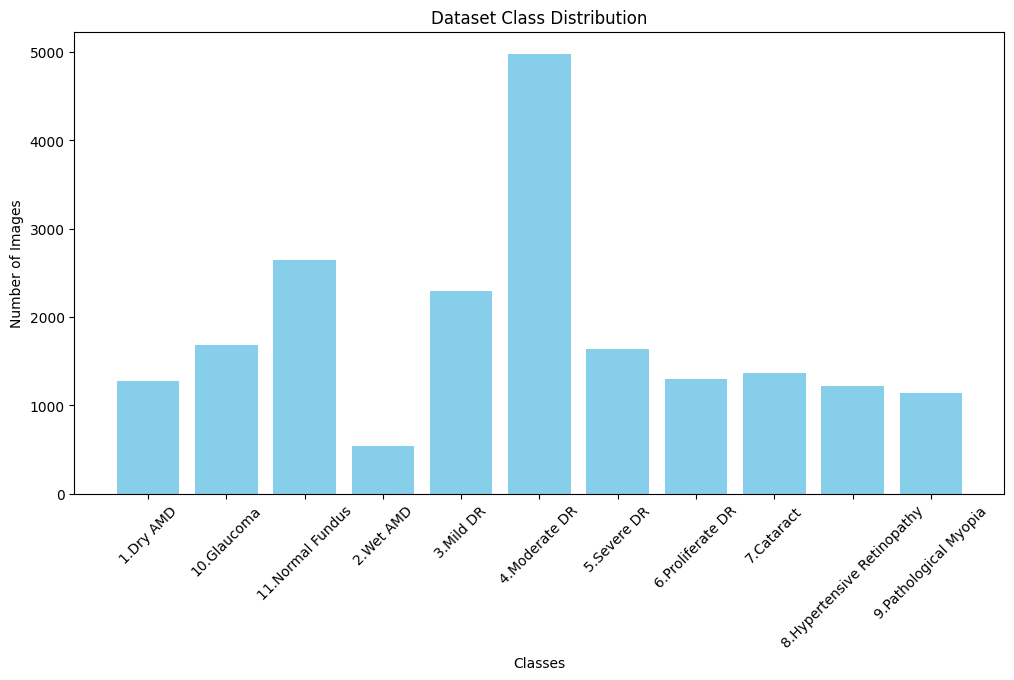

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Path to dataset
dataset_path = r"C:\Users\mgree\Downloads\CV_DATASET\Retinal Fundus Images"

# Check folders inside dataset
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

# List class names
classes = os.listdir(train_path)
print("Classes:", classes)

# Count images per class
image_count = {cls: len(os.listdir(os.path.join(train_path, cls))) for cls in classes}
print("Image count per class:", image_count)

# Plot class distribution
plt.figure(figsize=(12, 6))
plt.bar(image_count.keys(), image_count.values(), color='skyblue')
plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.show()


In [5]:
import os
import shutil

# Actual dataset path
dataset_path = r"C:\Users\mgree\Downloads\CV_DATASET\Retinal Fundus Images"

# Define binary dataset structure
binary_dataset_path = r"C:\Users\mgree\Downloads\CV_BINARY_DATASET"
os.makedirs(binary_dataset_path, exist_ok=True)
os.makedirs(os.path.join(binary_dataset_path, "CVD_Positive"), exist_ok=True)
os.makedirs(os.path.join(binary_dataset_path, "CVD_Negative"), exist_ok=True)

# Define positive and negative class labels (without numeric prefixes)
cvd_positive_classes = ["Hypertensive Retinopathy", "Severe DR", "Proliferate DR", "Pathological Myopia", "Wet AMD"]
cvd_negative_classes = ["Normal Fundus"]

# Function to clean folder names (remove numeric prefixes)
def clean_class_name(folder_name):
    return folder_name.split(".", 1)[-1]  # Removes number and dot (e.g., "8.Hypertensive Retinopathy" → "Hypertensive Retinopathy")

# Function to move images correctly
def move_images(source_folder, target_folder, class_labels):
    """Move images from source to target based on class labels"""
    for cls in os.listdir(source_folder):
        class_path = os.path.join(source_folder, cls)

        if not os.path.isdir(class_path):
            continue  # Skip if it's not a folder
        
        clean_name = clean_class_name(cls)  # Remove number prefixes
        
        if clean_name in class_labels:
            print(f"✅ Moving Images from {cls} → {target_folder}")

            for img in os.listdir(class_path):
                img_path = os.path.join(class_path, img)

                # Verify image file before copying
                if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                    shutil.copy(img_path, target_folder)
                else:
                    print(f"⚠ Skipped Non-Image File: {img}")

# Move images for train, test, and val
for dataset_type in ["train", "test", "val"]:
    dataset_split_path = os.path.join(dataset_path, dataset_type)

    move_images(dataset_split_path, os.path.join(binary_dataset_path, "CVD_Positive"), cvd_positive_classes)
    move_images(dataset_split_path, os.path.join(binary_dataset_path, "CVD_Negative"), cvd_negative_classes)

print("✅ Binary dataset created successfully with images!")


✅ Moving Images from 2.Wet AMD → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 5.Severe DR → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 6.Proliferate DR → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 8.Hypertensive Retinopathy → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 9.Pathological Myopia → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 11.Normal Fundus → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Negative
✅ Moving Images from 2.Wet AMD → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 5.Severe DR → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 6.Proliferate DR → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 8.Hypertensive Retinopathy → C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive
✅ Moving Images from 9.Pathological Myo

In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
binary_dataset_path = r"C:\Users\mgree\Downloads\CV_BINARY_DATASET"
processed_dataset_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET"
enhanced_path = os.path.join(processed_dataset_path, "Enhanced")
os.makedirs(enhanced_path, exist_ok=True)

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(binary_dataset_path, category)
    save_category_path = os.path.join(enhanced_path, category)
    os.makedirs(save_category_path, exist_ok=True)

    for img_name in tqdm(os.listdir(category_path), desc=f"Enhancing {category}"):
        img_path = os.path.join(category_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"⚠ Error loading image: {img_path}")
            continue

        # Apply CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(image)

        # Save
        cv2.imwrite(os.path.join(save_category_path, img_name), enhanced)

print("✅ Step 1: CLAHE Enhancement Complete!")


Enhancing CVD_Negative: 100%|██████████| 2874/2874 [00:47<00:00, 60.91it/s]

✅ Step 1: CLAHE Enhancement Complete!


In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
enhanced_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"
vessels_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Vessels"
os.makedirs(vessels_path, exist_ok=True)

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(enhanced_path, category)
    save_category_path = os.path.join(vessels_path, category)
    os.makedirs(save_category_path, exist_ok=True)

    for img_name in tqdm(os.listdir(category_path), desc=f"Extracting vessels {category}"):
        img_path = os.path.join(category_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"⚠ Error loading image: {img_path}")
            continue

        # Blood Vessel Extraction (Morphology)
        kernel = np.ones((3, 3), np.uint8)
        opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel, iterations=2)
        vessel_mask = cv2.absdiff(image, opened)

        # Save
        cv2.imwrite(os.path.join(save_category_path, img_name), vessel_mask)

print("✅ Step 2: Blood Vessel Extraction Complete!")


Extracting vessels CVD_Negative: 100%|██████████| 2874/2874 [00:47<00:00, 60.74it/s]

✅ Step 2: Blood Vessel Extraction Complete!


In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
enhanced_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"
optic_disc_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\OpticDisc"
os.makedirs(optic_disc_path, exist_ok=True)

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(enhanced_path, category)
    save_category_path = os.path.join(optic_disc_path, category)
    os.makedirs(save_category_path, exist_ok=True)

    for img_name in tqdm(os.listdir(category_path), desc=f"Detecting optic disc {category}"):
        img_path = os.path.join(category_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"⚠ Error loading image: {img_path}")
            continue

        # Apply CLAHE for better contrast
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        image_eq = clahe.apply(image)

        # Apply Gaussian Blur for noise reduction
        blurred = cv2.GaussianBlur(image_eq, (5, 5), 0)

        # Mask out the top part of the image to avoid false detections
        h, w = blurred.shape
        mask = np.zeros_like(blurred)
        mask[int(h * 0.2):int(h * 0.8), int(w * 0.2):int(w * 0.8)] = 255  # Focus on the central region
        masked_blurred = cv2.bitwise_and(blurred, blurred, mask=mask)

        # Detect optic disc using Hough Circle Transform
        circles = cv2.HoughCircles(masked_blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50,
                                   param1=80, param2=35, minRadius=30, maxRadius=80)

        # Create an empty mask
        optic_disc = np.zeros_like(image)

        # Draw detected circles
        if circles is not None:
            circles = np.uint16(np.around(circles))
            for x, y, r in circles[0, :]:
                cv2.circle(optic_disc, (x, y), r, 255, thickness=-1)  # Fill optic disc

                # Debugging: Draw circle on the original image
                debug_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
                cv2.circle(debug_img, (x, y), r, (0, 255, 0), 2)  # Draw green circle

                # Save debug visualization
                cv2.imwrite(os.path.join(save_category_path, f"{img_name}_debug.jpg"), debug_img)

        # Save optic disc mask
        cv2.imwrite(os.path.join(save_category_path, img_name), optic_disc)

print("✅ Step 3: Optic Disc Detection Complete!")


Detecting optic disc CVD_Negative: 100%|██████████| 2874/2874 [19:37<00:00,  2.44it/s]

✅ Step 3: Optic Disc Detection Complete!


In [7]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
enhanced_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"
edges_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Edges"
os.makedirs(edges_path, exist_ok=True)

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(enhanced_path, category)
    save_category_path = os.path.join(edges_path, category)
    os.makedirs(save_category_path, exist_ok=True)

    for img_name in tqdm(os.listdir(category_path), desc=f"Applying Canny Edge Detection {category}"):
        img_path = os.path.join(category_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"⚠ Error loading image: {img_path}")
            continue

        # Apply Canny Edge Detection
        edges = cv2.Canny(image, 50, 150)

        # Save
        cv2.imwrite(os.path.join(save_category_path, img_name), edges)

print("✅ Step 4: Canny Edge Detection Complete!")


Applying Canny Edge Detection CVD_Negative: 100%|██████████| 2874/2874 [00:41<00:00, 68.71it/s]

✅ Step 4: Canny Edge Detection Complete!


In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
enhanced_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"
lesion_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Lesions"
os.makedirs(lesion_path, exist_ok=True)

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(enhanced_path, category)
    save_category_path = os.path.join(lesion_path, category)
    os.makedirs(save_category_path, exist_ok=True)

    for img_name in tqdm(os.listdir(category_path), desc=f"Extracting Lesions {category}"):
        img_path = os.path.join(category_path, img_name)
        image = cv2.imread(img_path)

        if image is None:
            print(f"⚠ Error loading image: {img_path}")
            continue

        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)

        # Extract bright lesions (Exudates) using morphological closing
        _, bright_thresh = cv2.threshold(b_channel, 160, 255, cv2.THRESH_BINARY)
        kernel = np.ones((5, 5), np.uint8)
        bright_lesions = cv2.morphologyEx(bright_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

        # Extract dark lesions (Hemorrhages) using adaptive thresholding
        dark_lesions = cv2.adaptiveThreshold(l_channel, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                             cv2.THRESH_BINARY_INV, 15, 5)

        # Combine both lesions
        combined_lesions = cv2.bitwise_or(bright_lesions, dark_lesions)

        # Save result
        cv2.imwrite(os.path.join(save_category_path, img_name), combined_lesions)

print("✅ Step 5: Lesion Feature Extraction Complete!")


Extracting Lesions CVD_Negative: 100%|██████████| 2874/2874 [01:04<00:00, 44.43it/s]

✅ Step 5: Lesion Feature Extraction Complete!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage import measure, morphology
from skimage.filters import frangi
from tqdm import tqdm

processed_dataset_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET"
vessel_path = os.path.join(processed_dataset_path, "Vessels")
optic_disc_path = os.path.join(processed_dataset_path, "OpticDisc")
lesion_path = os.path.join(processed_dataset_path, "Lesions")
edges_path = os.path.join(processed_dataset_path, "Edges")

features = []

def vessel_density(vessel_image):
    return np.sum(vessel_image > 0) / vessel_image.size


def calculate_tortuosity(vessel_image):
    """Improved tortuosity metric from paper's Table 3"""
    skeleton = morphology.skeletonize(vessel_image > 0)
    labeled = measure.label(skeleton)
    props = measure.regionprops(labeled)
    tortuosities = []
    for prop in props:
        if prop.perimeter > 0:
            tortuosity = (prop.perimeter / (2 * np.sqrt(np.pi * prop.area))) - 1
            tortuosities.append(tortuosity)
    return np.mean(tortuosities) if tortuosities else 0

def calculate_bifurcation(vessel_image):
    """Simplified but robust branching metric"""
    try:
        # Skeletonize vessels
        skeleton = morphology.skeletonize(vessel_image > 0)
        
        # Find branch points
        branch_points = np.zeros_like(skeleton)
        kernel = np.array([[1, 1, 1],
                          [1,10, 1],
                          [1, 1, 1]], dtype=np.uint8)
        
        conv = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel)
        branch_points = (conv >= 13).astype(np.uint8)  # Branch points have >=3 neighbors
        
        return np.sum(branch_points) / np.sum(skeleton)  # Branch point density
        
    except Exception as e:
        print(f"Simple bifurcation error: {e}")
        return 0.0

def cup_disc_ratio(disc_image):
    contours, _ = cv2.findContours(disc_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return 0
    areas = [cv2.contourArea(cnt) for cnt in contours]
    max_idx = np.argmax(areas)
    return np.sqrt(areas[max_idx]) / np.sqrt(disc_image.size)  # Normalized size ratio

def lesion_count(lesion_image):
    return np.sum(lesion_image > 0)

def edge_complexity(edge_image):
    return np.sum(edge_image > 0) / edge_image.size

# Process images
for category in ["CVD_Positive", "CVD_Negative"]:
    category_vessel = os.path.join(vessel_path, category)
    category_disc = os.path.join(optic_disc_path, category)
    category_lesion = os.path.join(lesion_path, category)
    category_edges = os.path.join(edges_path, category)
    label = 1 if category == "CVD_Positive" else 0
    
    for img_name in tqdm(os.listdir(category_vessel), desc=f"Extracting features {category}"):
        img_path_vessel = os.path.join(category_vessel, img_name)
        img_path_disc = os.path.join(category_disc, img_name)
        img_path_lesion = os.path.join(category_lesion, img_name)
        img_path_edges = os.path.join(category_edges, img_name)
        
        vessel_img = cv2.imread(img_path_vessel, cv2.IMREAD_GRAYSCALE)
        disc_img = cv2.imread(img_path_disc, cv2.IMREAD_GRAYSCALE)
        lesion_img = cv2.imread(img_path_lesion, cv2.IMREAD_GRAYSCALE)
        edge_img = cv2.imread(img_path_edges, cv2.IMREAD_GRAYSCALE)
        
        if any(img is None for img in [vessel_img, disc_img, lesion_img, edge_img]):
            print(f"⚠ Skipping {img_name} due to missing data")
            continue
        
        features.append([
    img_name,
    vessel_density(vessel_img),
    calculate_tortuosity(vessel_img),  # NEW: Improved tortuosity
    calculate_bifurcation(vessel_img), # NEW: Branching analysis
    cup_disc_ratio(disc_img),
    lesion_count(lesion_img),
    edge_complexity(edge_img),
   
    label
])

# Save extracted features to CSV
columns = ["Image", "VesselDensity", "Tortuosity"," Bifurcation","CupDiscRatio", "LesionCount", "EdgeComplexity", "Label"]
df = pd.DataFrame(features, columns=columns)
df.to_csv("cvd_features.csv", index=False)  

print("✅ Feature extraction complete! Data saved in cvd_features.csv")


Extracting features CVD_Negative: 100%|██████████| 2874/2874 [10:31<00:00,  4.55it/s]


✅ Feature extraction complete! Data saved in cvd_features.csv


In [14]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage import morphology
from tqdm import tqdm

# ===== ONLY DEFINE NEW FEATURE FUNCTIONS =====
def fractal_dimension(image, threshold=0.9):
    """Calculate fractal dimension using box counting method (simplified)"""
    binary = image > threshold * np.max(image)
    p = min(binary.shape)
    n = 2**int(np.floor(np.log(p)/np.log(2)))  # Convert to integer
    sizes = 2**np.arange(int(np.log(n)/np.log(2)), 1, -1)  # Ensure integer indices
    counts = []
    for size in sizes:
        size = int(size)  # Convert size to integer
        if size < 1: size = 1  # Prevent zero division
        counts.append(np.count_nonzero(binary[::size, ::size]))
    if len(sizes) < 2: return 1.0  # Default value if not enough points
    return -np.polyfit(np.log(sizes), np.log(counts), 1)[0]

def avr_ratio(vessel_image):
    contours, _ = cv2.findContours(vessel_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE) 
    diameters = [cv2.minEnclosingCircle(cnt)[1]*2 for cnt in contours]
    if len(diameters) < 2: return 0.5
    diameters_sorted = sorted(diameters)
    return np.mean(diameters_sorted[:len(diameters)//2]) / np.mean(diameters_sorted[len(diameters)//2:])

def calculate_crae_crve(vessel_image):
    contours, _ = cv2.findContours(vessel_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    diameters = [cv2.minEnclosingCircle(cnt)[1]*2 for cnt in contours]
    if len(diameters) < 2: return (0.0, 0.0)
    diameters_sorted = sorted(diameters)
    return (np.mean(diameters_sorted[:len(diameters)//2]), np.mean(diameters_sorted[len(diameters)//2:]))

# ===== LOAD EXISTING CSV =====
existing_df = pd.read_csv("cvd_features.csv")  # Your existing features

# ===== ONLY PROCESS VESSEL IMAGES FOR NEW FEATURES =====
vessel_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Vessels"
new_features = []

for category in ["CVD_Positive", "CVD_Negative"]:
    category_path = os.path.join(vessel_path, category)
    
    for img_name in tqdm(os.listdir(category_path), desc=f"Extracting new features {category}"):
        img_path = os.path.join(category_path, img_name)
        vessel_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if vessel_img is None:
            print(f"⚠ Skipping {img_name}")
            new_features.append([img_name, np.nan, np.nan, np.nan, np.nan])
            continue
        
        # Calculate only the new features
        try:
            fractal_dim = fractal_dimension(vessel_img)
            avr = avr_ratio(vessel_img)
            crae, crve = calculate_crae_crve(vessel_img)
            new_features.append([img_name, fractal_dim, avr, crae, crve])
        except Exception as e:
            print(f"⚠ Error processing {img_name}: {str(e)}")
            new_features.append([img_name, np.nan, np.nan, np.nan, np.nan])

# ===== MERGE WITH EXISTING DATA =====
new_df = pd.DataFrame(new_features, columns=["Image", "FractalDim", "AVR", "CRAE", "CRVE"])
merged_df = pd.merge(existing_df, new_df, on="Image", how="left")

# Save updated CSV
merged_df.to_csv("updated_cvd_features.csv", index=False)
print("✅ Successfully added new features to existing dataset!")

Extracting new features CVD_Positive:   0%|          | 0/6354 [00:00<?, ?it/s]C:\Users\mgree\AppData\Local\Temp\ipykernel_24556\107766308.py:21: RuntimeWarning: divide by zero encountered in log
  return -np.polyfit(np.log(sizes), np.log(counts), 1)[0]
Extracting new features CVD_Negative: 100%|██████████| 2874/2874 [05:18<00:00,  9.02it/s]


✅ Successfully added new features to existing dataset!


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage import morphology
from tqdm import tqdm

class RetinalFeatureExtractor:
    """
    A class for extracting retinal features from vessel images including:
    - Fractal Dimension (FractalDim)
    - Arteriole-to-Venule Ratio (AVR)
    - Central Retinal Arteriolar Equivalent (CRAE)
    - Central Retinal Venular Equivalent (CRVE)
    """
    
    def __init__(self, vessel_path, output_csv="updated_cvd_features.csv"):
        """
        Initialize the feature extractor
        
        Args:
            vessel_path: Path to directory containing vessel images
            output_csv: Path to save the output CSV file
        """
        self.vessel_path = vessel_path
        self.output_csv = output_csv
        
    def fractal_dimension(self, image, threshold=0.5):
        """
        Calculate fractal dimension using box counting method
        
        Args:
            image: Input grayscale vessel image
            threshold: Binarization threshold (default: 0.5)
            
        Returns:
            float: Fractal dimension (1.0-2.0) or np.nan if calculation fails
        """
        try:
            # Preprocess and binarize image
            binary = (image > threshold * np.max(image)).astype(np.uint8)
            
            # Validate input
            if np.sum(binary) < 100 or min(binary.shape) < 32:
                return np.nan
                
            # Generate box sizes (powers of 2)
            sizes = 2**np.arange(1, int(np.log2(min(binary.shape))))
            
            # Box counting
            counts = []
            for size in sizes:
                box = binary[::size, ::size]
                count = np.count_nonzero(box)
                if count > 0:  # Skip empty boxes
                    counts.append(count)
            
            # Require sufficient points for regression
            if len(counts) < 4:
                return np.nan
                
            # Linear regression on log-log plot
            coeffs = np.polyfit(np.log(sizes[:len(counts)]), np.log(counts), 1)
            return np.clip(-coeffs[0], 1.0, 2.0)  # Clamp to valid range
            
        except Exception as e:
            print(f"Fractal dimension error: {e}")
            return np.nan
    
    def avr_ratio(self, vessel_image):
        """
        Calculate Arteriole-to-Venule Ratio (AVR)
        
        Args:
            vessel_image: Binary vessel image
            
        Returns:
            float: AVR ratio or 0.5 if calculation fails
        """
        try:
            contours, _ = cv2.findContours(vessel_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
            diameters = [cv2.minEnclosingCircle(cnt)[1]*2 for cnt in contours]
            
            if len(diameters) < 2:
                return 0.5
                
            diameters_sorted = sorted(diameters)
            half = len(diameters)//2
            return np.mean(diameters_sorted[:half]) / np.mean(diameters_sorted[half:])
            
        except Exception as e:
            print(f"AVR calculation error: {e}")
            return 0.5
    
    def calculate_crae_crve(self, vessel_image):
        """
        Calculate CRAE and CRVE values
        
        Args:
            vessel_image: Binary vessel image
            
        Returns:
            tuple: (CRAE, CRVE) or (0.0, 0.0) if calculation fails
        """
        try:
            contours, _ = cv2.findContours(vessel_image, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
            diameters = [cv2.minEnclosingCircle(cnt)[1]*2 for cnt in contours]
            
            if len(diameters) < 2:
                return (0.0, 0.0)
                
            diameters_sorted = sorted(diameters)
            half = len(diameters)//2
            return (
                np.mean(diameters_sorted[:half]),
                np.mean(diameters_sorted[half:])
            )
            
        except Exception as e:
            print(f"CRAE/CRVE calculation error: {e}")
            return (0.0, 0.0)
    
    def process_images(self, existing_features_path="cvd_features.csv"):
        """
        Process all vessel images and merge with existing features
        
        Args:
            existing_features_path: Path to existing feature CSV file
        """
        # Load existing features
        existing_df = pd.read_csv(existing_features_path)
        new_features = []
        
        # Process each category
        for category in ["CVD_Positive", "CVD_Negative"]:
            category_path = os.path.join(self.vessel_path, category)
            image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_name in tqdm(image_files, desc=f"Processing {category}"):
                img_path = os.path.join(category_path, img_name)
                
                try:
                    # Load and validate image
                    vessel_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if vessel_img is None:
                        raise ValueError("Failed to load image")
                    
                    # Calculate features
                    features = [
                        img_name,
                        self.fractal_dimension(vessel_img),
                        self.avr_ratio(vessel_img),
                        *self.calculate_crae_crve(vessel_img)
                    ]
                    new_features.append(features)
                    
                    # Debug output
                    print(f"{img_name}: FD={features[1]:.2f}, AVR={features[2]:.2f}, "
                          f"CRAE={features[3]:.2f}, CRVE={features[4]:.2f}")
                          
                except Exception as e:
                    print(f"⚠ Error processing {img_name}: {str(e)}")
                    new_features.append([img_name, np.nan, np.nan, np.nan, np.nan])
        
        # Merge and save results
        new_df = pd.DataFrame(new_features, 
                             columns=["Image", "FractalDim", "AVR", "CRAE", "CRVE"])
        merged_df = pd.merge(existing_df, new_df, on="Image", how="left")
        merged_df.to_csv(self.output_csv, index=False)
        print(f"✅ Features saved to {self.output_csv}")


if __name__ == "__main__":
    # Configuration
    VESSEL_PATH = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Vessels"
    OUTPUT_CSV = "updated_cvd_features.csv"
    
    # Run feature extraction
    extractor = RetinalFeatureExtractor(VESSEL_PATH, OUTPUT_CSV)
    extractor.process_images()

Processing CVD_Positive:   0%|          | 2/6354 [00:00<22:35,  4.68it/s]

Hypertensive Retinopathy1024_left_0_5543.jpeg: FD=1.56, AVR=0.55, CRAE=1.99, CRVE=3.59
Hypertensive Retinopathy1024_left_0_7388.jpeg: FD=2.00, AVR=0.54, CRAE=1.98, CRVE=3.68


Processing CVD_Positive:   0%|          | 4/6354 [00:00<18:46,  5.64it/s]

Hypertensive Retinopathy1024_left_0_7694.jpeg: FD=1.64, AVR=0.55, CRAE=1.98, CRVE=3.62
Hypertensive Retinopathy1024_left_0_7927.jpeg: FD=1.81, AVR=0.54, CRAE=1.97, CRVE=3.68


Processing CVD_Positive:   0%|          | 6/6354 [00:01<17:20,  6.10it/s]

...

Processing CVD_Negative: 100%|█████████▉| 2873/2874 [09:11<00:00,  5.53it/s]

996_right.jpeg: FD=1.49, AVR=0.57, CRAE=1.98, CRVE=3.46
99_right.jpeg: FD=nan, AVR=0.42, CRAE=2.02, CRVE=4.79


Processing CVD_Negative: 100%|██████████| 2874/2874 [09:12<00:00,  5.20it/s]

9_left.jpeg: FD=1.79, AVR=0.70, CRAE=1.98, CRVE=2.83


✅ Features saved to updated_cvd_features.csv


In [6]:
import pandas as pd
df = pd.read_csv("updated_cvd_features.csv")
print(df.head())  # Verify columns: Image, VesselDensity, Tortuosity, ..., FractalDim, AVR, CRAE, CRVE, Label
print(df.isnull().sum())  # Check for missing values

                                           Image  VesselDensity  Tortuosity  \
0  Hypertensive Retinopathy1024_left_0_5543.jpeg       0.715858    0.006134   
1  Hypertensive Retinopathy1024_left_0_7388.jpeg       0.744907    0.005814   
2  Hypertensive Retinopathy1024_left_0_7694.jpeg       0.728172    0.006554   
3  Hypertensive Retinopathy1024_left_0_7927.jpeg       0.671757    0.007713   
4  Hypertensive Retinopathy1024_left_0_8603.jpeg       0.722599    0.006828   

   CupDiscRatio  LesionCount  EdgeComplexity  Label  FractalDim       AVR  \
0      0.774226       140550        0.486820      1    1.559228  0.552865   
1      0.740627       146723        0.512108      1    2.000000  0.538703   
2      0.788175       143023        0.496357      1    1.641318  0.546537   
3      0.765563       131109        0.446716      1    1.807967  0.536340   
4      0.756795       142154        0.492138      1    1.587952  0.543384   

       CRAE      CRVE  
0  1.985813  3.591860  
1  1.982622  3

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
enhanced_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"
augmented_path = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Augmented_Enhanced"
os.makedirs(augmented_path, exist_ok=True)

# Define complete augmentation parameters
def get_augmenter(aggressive=False):
    if aggressive:
        return {
            'rotation_range': 25,          # ±25 degrees
            'width_shift_range': 0.15,     # ±15% width shift
            'height_shift_range': 0.15,    # ±15% height shift
            'brightness_range': [0.8, 1.2], # ±20% brightness
            'horizontal_flip': True,
            'vertical_flip': True,
            'fill_mode': 'reflect'
        }
    else:
        return {
            'rotation_range': 10,          # ±10 degrees
            'width_shift_range': 0.05,     # ±5% width shift
            'height_shift_range': 0.05,    # ±5% height shift
            'brightness_range': [0.9, 1.1], # ±10% brightness
            'horizontal_flip': True,
            'vertical_flip': False,        # No vertical flip for mild augmentation
            'fill_mode': 'reflect'
        }

def augment_image(img, params):
    """Apply augmentation to a single grayscale image"""
    rows, cols = img.shape
    
    # Random rotation
    angle = np.random.uniform(-params['rotation_range'], params['rotation_range'])
    M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
    img = cv2.warpAffine(img, M, (cols, rows), borderMode=cv2.BORDER_REFLECT)
    
    # Random shifts
    tx = np.random.uniform(-params['width_shift_range'], params['width_shift_range']) * cols
    ty = np.random.uniform(-params['height_shift_range'], params['height_shift_range']) * rows
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (cols, rows), borderMode=cv2.BORDER_REFLECT)
    
    # Random brightness
    img = img * np.random.uniform(params['brightness_range'][0], params['brightness_range'][1])
    img = np.clip(img, 0, 255).astype(np.uint8)
    
    # Random flips
    if params['horizontal_flip'] and np.random.rand() > 0.5:
        img = cv2.flip(img, 1)
    if params.get('vertical_flip', False) and np.random.rand() > 0.5:
        img = cv2.flip(img, 0)
        
    return img

# Process images
for class_name in ["CVD_Positive", "CVD_Negative"]:
    class_path = os.path.join(enhanced_path, class_name)
    save_path = os.path.join(augmented_path, class_name)
    os.makedirs(save_path, exist_ok=True)
    
    params = get_augmenter(aggressive=(class_name == "CVD_Negative"))
    
    for img_name in tqdm(os.listdir(class_path), desc=f"Augmenting {class_name}"):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"⚠ Skipping {img_path}")
            continue
        
        # Save original
        cv2.imwrite(os.path.join(save_path, img_name), img)
        
        # Generate augmented versions
        n_aug = 3 if class_name == "CVD_Negative" else 1
        for i in range(n_aug):
            try:
                augmented = augment_image(img.copy(), params)
                cv2.imwrite(os.path.join(save_path, f"aug_{i}_{img_name}"), augmented)
            except Exception as e:
                print(f"⚠ Error augmenting {img_name}: {str(e)}")
                continue

print(f"✅ Augmentation complete! Enhanced images saved in:\n{augmented_path}")

Augmenting CVD_Negative: 100%|██████████| 2874/2874 [01:52<00:00, 25.47it/s]

✅ Augmentation complete! Enhanced images saved in:
C:\Users\mgree\Downloads\Processed_CV_DATASET\Augmented_Enhanced


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load features
df = pd.read_csv("updated_cvd_features.csv")

# Split data (stratified by label)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.25, stratify=train_df['Label'], random_state=42)  # 60-20-20 split

# Save splits
train_df.to_csv("train_features.csv", index=False)
val_df.to_csv("val_features.csv", index=False)
test_df.to_csv("test_features.csv", index=False)

print("✅ Data split complete (Train/Val/Test)")

✅ Data split complete (Train/Val/Test)



Starting training...


C:\Users\mgree\AppData\Local\Temp\ipykernel_19580\177716492.py:181: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)



Training on 5536 samples, validating on 1846 samples


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      1,280 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1408)      │          0 │ efficientnetb0[0… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    360,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

Epoch 1/50


c:\Users\mgree\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['image_input', 'feature_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7411 - auc: 0.8321 - loss: 0.5808 - precision: 0.8869 - recall: 0.7114

c:\Users\mgree\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\mgree\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['image_input', 'feature_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(



Epoch 1: val_auc improved from -inf to 0.94371, saving model to best_model.keras
346/346 ━━━━━━━━━━━━━━━━━━━━ 276s 704ms/step - accuracy: 0.7412 - auc: 0.8322 - loss: 0.5806 - precision: 0.8870 - recall: 0.7115 - val_accuracy: 0.8635 - val_auc: 0.9437 - val_loss: 0.3862 - val_precision: 0.9489 - val_recall: 0.8474 - learning_rate: 1.0000e-04
Epoch 2/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7971 - auc: 0.8837 - loss: 0.4550 - precision: 0.9033 - recall: 0.7923
Epoch 2: val_auc did not improve from 0.94371
346/346 ━━━━━━━━━━━━━━━━━━━━ 250s 670ms/step - accuracy: 0.7971 - auc: 0.8837 - loss: 0.4549 - precision: 0.9032 - recall: 0.7924 - val_accuracy: 0.8716 - val_auc: 0.9418 - val_loss: 0.3029 - val_precision: 0.9238 - val_recall: 0.8867 - learning_rate: 1.0000e-04
Epoch 3/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8293 - auc: 0.8998 - loss: 0.3901 - precision: 0.8937 - recall: 0.8551
Epoch 3: val_auc improved from 0.94371 to 0.94524, saving model to b

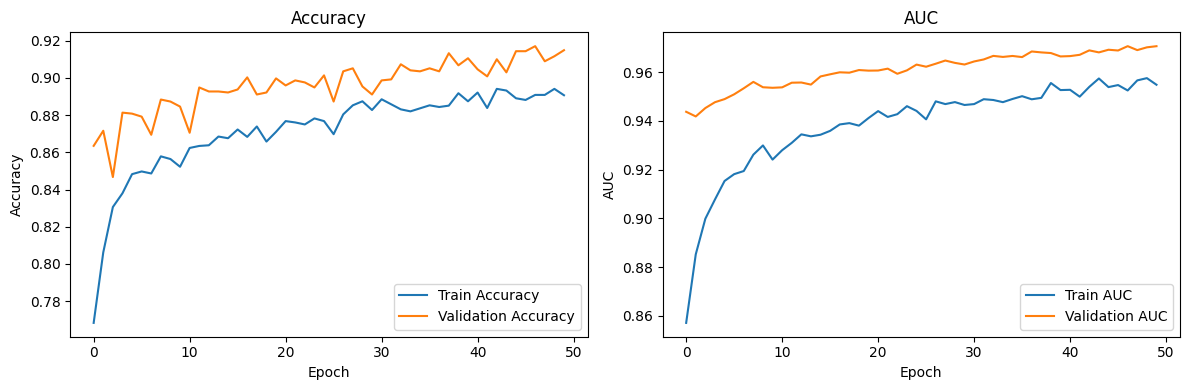


Evaluating on test set...


C:\Users\mgree\AppData\Local\Temp\ipykernel_19580\177716492.py:247: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna(train_df[col].mean(), inplace=True)
c:\Users\mgree\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be i

116/116 ━━━━━━━━━━━━━━━━━━━━ 58s 434ms/step - accuracy: 0.9305 - auc: 0.9713 - loss: 0.2078 - precision: 0.9332 - recall: 0.9691

Test Set Evaluation:
Loss: 0.2131
Accuracy: 0.9220
AUC: 0.9707
Precision: 0.9298
Recall: 0.9591


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Configuration - UPDATE THESE PATHS TO MATCH YOUR SYSTEM
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50
AUGMENTED_IMAGE_PATH = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Augmented_Enhanced"
BASE_IMAGE_PATH = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced"

# 1. Data Pipeline --------------------------------------------------

class RetinalDataGenerator(tf.keras.utils.Sequence):
    """Custom data generator combining images and features"""
    def __init__(self, df, image_dir, batch_size=32, shuffle=True):
        self.df = df.copy()
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # Dynamically get feature columns (exclude non-feature columns)
        non_feature_cols = ['Image', 'Label']
        self.feature_cols = [col for col in self.df.columns if col not in non_feature_cols]
        
        # Initialize and fit scaler
        self.scaler = StandardScaler()
        self.scaler.fit(self.df[self.feature_cols].values)
        
        # Verify images exist and create valid indices list
        self.valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = self._get_image_path(row)
            if os.path.exists(img_path):
                self.valid_indices.append(idx)
            else:
                print(f"⚠ Image not found: {img_path}")
        
        self.n = len(self.valid_indices)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.valid_indices[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        X_img, X_feat, y = self._get_data(batch_df)
        return (X_img, X_feat), y
    
    def _get_data(self, batch_df):
        # Load and process images
        X_img = np.array([self._load_image(row) for _, row in batch_df.iterrows()])
        
        # Scale features
        X_feat = self.scaler.transform(batch_df[self.feature_cols].values)
        
        # Get labels
        y = batch_df['Label'].values
        
        return X_img, X_feat, y
    
    def _get_image_path(self, row):
        """Get the correct image path, trying augmented first then falling back to base"""
        class_folder = 'Positive' if row['Label'] else 'Negative'
        # Try augmented path first
        img_path = os.path.join(self.image_dir, f"CVD_{class_folder}", row['Image'])
        if not os.path.exists(img_path):
            # Fall back to base path
            img_path = os.path.join(BASE_IMAGE_PATH, f"CVD_{class_folder}", row['Image'])
        return img_path
    
    def _load_image(self, row):
        """Load and preprocess a single image"""
        img_path = self._get_image_path(row)
        
        try:
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # Ensure 3 channels
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
            return img.numpy()
        except Exception as e:
            print(f"⚠ Error loading {img_path}: {str(e)}")
            # Return blank image if loading fails
            return np.zeros((*IMG_SIZE, 3), dtype=np.float32)
    
    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.valid_indices)

# 2. Model Architecture ---------------------------------------------

def create_hybrid_model(num_features):
    """Create multi-input hybrid model with EfficientNet backbone"""
    # Image branch
    img_input = layers.Input(shape=(*IMG_SIZE, 3), name='image_input')
    base_model = applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        pooling='avg'
    )
    base_model.trainable = False  # Freeze pretrained weights initially
    img_features = base_model(img_input)
    
    # Feature branch
    feat_input = layers.Input(shape=(num_features,), name='feature_input')
    feat_dense = layers.Dense(128, activation='relu')(feat_input)
    feat_dense = layers.BatchNormalization()(feat_dense)
    feat_dense = layers.Dropout(0.3)(feat_dense)
    
    # Combined branches
    combined = layers.Concatenate()([img_features, feat_dense])
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=[img_input, feat_input], outputs=output)

# 3. Training Setup -------------------------------------------------

def setup_callbacks():
    """Configure training callbacks"""
    return [
        callbacks.ModelCheckpoint(
            "best_model.keras",
            monitor='val_auc',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        callbacks.CSVLogger('training_log.csv')
    ]

def compile_model(model):
    """Compile model with appropriate metrics"""
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

# 4. Training Execution ---------------------------------------------

def train_model():
    # Load data
    train_df = pd.read_csv("train_features.csv")
    val_df = pd.read_csv("val_features.csv")
    
    # Handle NaN values by filling with column means
    for df in [train_df, val_df]:
        for col in df.columns:
            if df[col].dtype in [np.float64, np.int64] and col != 'Label':
                df[col].fillna(df[col].mean(), inplace=True)
    
    # Create data generators
    train_gen = RetinalDataGenerator(train_df, AUGMENTED_IMAGE_PATH, BATCH_SIZE)
    val_gen = RetinalDataGenerator(val_df, BASE_IMAGE_PATH, BATCH_SIZE, shuffle=False)
    
    print(f"\nTraining on {train_gen.n} samples, validating on {val_gen.n} samples")
    
    # Create and compile model
    model = create_hybrid_model(len(train_gen.feature_cols))
    model = compile_model(model)
    model.summary()
    
    # Train model
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=setup_callbacks(),
        verbose=1
    )
    
    # Save final model
    model.save("retinal_cvd_final_model.keras")
    
    # Plot training history
    plot_training_history(history)
    
    return model, history

def plot_training_history(history):
    """Plot training metrics"""
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot AUC
    plt.subplot(1, 2, 2)
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title('AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()

# 5. Evaluation -----------------------------------------------------

def evaluate_model():
    """Evaluate model on test set"""
    test_df = pd.read_csv("test_features.csv")
    
    # Handle NaN values using training data means
    train_df = pd.read_csv("train_features.csv")
    for col in test_df.columns:
        if test_df[col].dtype in [np.float64, np.int64] and col != 'Label':
            test_df[col].fillna(train_df[col].mean(), inplace=True)
    
    test_gen = RetinalDataGenerator(test_df, BASE_IMAGE_PATH, BATCH_SIZE, shuffle=False)
    
    model = tf.keras.models.load_model("best_model.keras")
    results = model.evaluate(test_gen)
    
    print("\nTest Set Evaluation:")
    print(f"Loss: {results[0]:.4f}")
    print(f"Accuracy: {results[1]:.4f}")
    print(f"AUC: {results[2]:.4f}")
    print(f"Precision: {results[3]:.4f}")
    print(f"Recall: {results[4]:.4f}")
    
    return results

# Main Execution ----------------------------------------------------
6
if __name__ == "__main__":
    # Configure GPU
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU config error: {e}")
    
    # Clear session and train
    tf.keras.backend.clear_session()
    print("Starting training...")
    model, history = train_model()
    
    # Evaluate
    print("\nEvaluating on test set...")
    test_results = evaluate_model()

In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Configuration (same as your training setup)
AUGMENTED_IMAGE_PATH = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Augmented_Enhanced"
BATCH_SIZE = 16

def save_feature_scaler():
    """Save the feature scaler from training data without retraining"""
    # Load training data
    train_df = pd.read_csv("train_features.csv")
    
    # Handle NaN values (same as in training)
    for col in train_df.columns:
        if train_df[col].dtype in [np.float64, np.int64] and col != 'Label':
            train_df[col].fillna(train_df[col].mean(), inplace=True)
    
    # Create a temporary generator to get the scaler
    class TempGenerator:
        def __init__(self, df):
            non_feature_cols = ['Image', 'Label']
            self.feature_cols = [col for col in df.columns if col not in non_feature_cols]
            self.scaler = StandardScaler()
            self.scaler.fit(df[self.feature_cols].values)
    
    # Get the fitted scaler
    temp_gen = TempGenerator(train_df)
    
    # Save the scaler
    joblib.dump(temp_gen.scaler, 'feature_scaler.save')
    print("✅ Feature scaler saved to feature_scaler.save")
    
    # Verify the columns order
    print("\nFeature columns order:")
    print(temp_gen.feature_cols)
    
    # Show sample scaling
    sample_features = train_df.iloc[0][temp_gen.feature_cols].values.reshape(1, -1)
    print("\nSample scaling check:")
    print("Original values:", sample_features)
    print("Scaled values:", temp_gen.scaler.transform(sample_features))

if __name__ == "__main__":
    # Check if training data exists
    if not os.path.exists("train_features.csv"):
        print("❌ Error: train_features.csv not found")
    else:
        save_feature_scaler()

✅ Feature scaler saved to feature_scaler.save

Feature columns order:
['VesselDensity', 'Tortuosity', 'CupDiscRatio', 'LesionCount', 'EdgeComplexity', 'FractalDim', 'AVR', 'CRAE', 'CRVE']

Sample scaling check:
Original values: [[0.7220036977958236 0.0032854190835266 0.691495570762171 449681
  0.4695351018706497 1.872259076382771 0.4568193378220886
  2.1648671914490207 4.739000765094893]]
Scaled values: [[ 0.57850489 -0.45576895 -0.44919996  1.20554557  0.38345718  0.36453364
  -0.50057966  4.38325596  0.88654665]]


C:\Users\mgree\AppData\Local\Temp\ipykernel_23832\4093999918.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)


In [20]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

def save_feature_scaler():
    """Save feature scaler with 9 features (excluding bifurcation)"""
    if not os.path.exists("train_features.csv"):
        print("❌ Error: train_features.csv not found")
        return

    # Load training data
    train_df = pd.read_csv("train_features.csv")
    
    # Define the 9 expected features (EXCLUDING BIFURCATION)
    expected_features = [
        'VesselDensity',
        'Tortuosity',
        'CupDiscRatio',
        'LesionCount',
        'EdgeComplexity',
        'FractalDim',
        'AVR',
        'CRAE',
        'CRVE'
    ]
    
    # Verify all expected features exist
    missing_features = [f for f in expected_features if f not in train_df.columns]
    if missing_features:
        raise ValueError(f"Missing features in training data: {missing_features}")
    
    # Handle NaN values
    for col in expected_features:
        train_df[col].fillna(train_df[col].mean(), inplace=True)
    
    # Create and fit scaler
    scaler = StandardScaler()
    scaler.fit(train_df[expected_features].values)
    
    # Save scaler with metadata
    scaler_package = {
        'version': '1.2',
        'features': expected_features,
        'scaler': scaler,
        'date': pd.Timestamp.now().isoformat()
    }
    joblib.dump(scaler_package, 'feature_scaler.save')
    
    print("✅ Feature scaler saved successfully (9 features, no bifurcation)")
    print("Feature order:", expected_features)

if __name__ == "__main__":
    save_feature_scaler()

✅ Feature scaler saved successfully (9 features, no bifurcation)
Feature order: ['VesselDensity', 'Tortuosity', 'CupDiscRatio', 'LesionCount', 'EdgeComplexity', 'FractalDim', 'AVR', 'CRAE', 'CRVE']


C:\Users\mgree\AppData\Local\Temp\ipykernel_23832\6719559.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
